# Spotify Streaming History Deep Dive

This notebook analyzes Jason Vile's personal Spotify streaming history using Python and common data analysis tools.

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

data_dir = Path('.').resolve()
data_dir

Matplotlib is building the font cache; this may take a moment.


WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History')

In [2]:
json_files = sorted([p for p in data_dir.glob('Streaming_History_Audio_*.json')])
json_files

[WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2018-2020_0.json'),
 WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2020-2021_2.json'),
 WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2020_1.json'),
 WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2021-2024_3.json'),
 WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2024-2025_4.json'),
 WindowsPath('C:/Users/The/Desktop/my_spotify_data/Spotify Extended Streaming History/Streaming_History_Audio_2025-2026_5.json')]

In [3]:
def load_history(files):
    records = []
    for path in files:
        with open(path, 'r', encoding='utf-8') as f:
            part = json.load(f)
        for row in part:
            row['source_file'] = path.name
        records.extend(part)
    return pd.DataFrame(records)

df = load_history(json_files)
df.shape

(80430, 24)

In [4]:
df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,source_file
0,2018-11-26T21:10:30Z,"Android OS 8.0.0 API 26 (samsung, SM-J600F)",0,SA,2.89.147.213,Happy Now,Kygo,Happy Now,spotify:track:14sOS5L36385FJ3OL8hew4,None,...,None,None,fwdbtn,backbtn,False,False,False,NaN,False,Streaming_History_Audio_2018-2020_0.json
1,2018-11-26T21:10:30Z,"Android OS 8.0.0 API 26 (samsung, SM-J600F)",9147,SA,2.89.147.213,come out and play,Billie Eilish,come out and play,spotify:track:7wC5eZcFS1Q1BsQ35DU6H4,None,...,None,None,playbtn,fwdbtn,False,False,False,NaN,False,Streaming_History_Audio_2018-2020_0.json
2,2018-11-26T21:10:49Z,"Android OS 8.0.0 API 26 (samsung, SM-J600F)",7812,SA,2.89.147.213,come out and play,Billie Eilish,come out and play,spotify:track:7wC5eZcFS1Q1BsQ35DU6H4,None,...,None,None,backbtn,fwdbtn,False,False,False,NaN,False,Streaming_History_Audio_2018-2020_0.json
3,2018-11-26T21:12:31Z,"Android OS 8.0.0 API 26 (samsung, SM-J600F)",34792,SA,2.89.147.213,If Walls Could Talk,5 Seconds of Summer,Youngblood - Deluxe,spotify:track:0nCVLAhIUrLQ34Vw5vTXNP,None,...,None,None,clickrow,endplay,True,False,False,NaN,False,Streaming_History_Audio_2018-2020_0.json
4,2018-11-26T21:12:38Z,"Android OS 8.0.0 API 26 (samsung, SM-J600F)",5118,SA,2.89.147.213,Mo Bamba,Sheck Wes,MUDBOY,spotify:track:1xzBco0xcoJEDXktl7Jxrr,None,...,None,None,clickrow,endplay,True,False,False,NaN,False,Streaming_History_Audio_2018-2020_0.json


In [5]:
df['ts'] = pd.to_datetime(df['ts'])
df['date'] = df['ts'].dt.date
df['year'] = df['ts'].dt.year
df['month'] = df['ts'].dt.to_period('M')
df['dayofweek'] = df['ts'].dt.day_name()
df['hour'] = df['ts'].dt.hour
df['minutes_played'] = df['ms_played'] / 1000 / 60
df['track'] = df['master_metadata_track_name']
df['artist'] = df['master_metadata_album_artist_name']
df['album'] = df['master_metadata_album_album_name']
df[['ts', 'minutes_played', 'track', 'artist']].head()

C:\Users\The\AppData\Local\Temp\ipykernel_3108\2434747727.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['ts'].dt.to_period('M')


,ts,minutes_played,track,artist
0,2018-11-26 21:10:30+00:00,0.000000,Happy Now,Kygo
1,2018-11-26 21:10:30+00:00,0.152450,come out and play,Billie Eilish
2,2018-11-26 21:10:49+00:00,0.130200,come out and play,Billie Eilish
3,2018-11-26 21:12:31+00:00,0.579867,If Walls Could Talk,5 Seconds of Summer
4,2018-11-26 21:12:38+00:00,0.085300,Mo Bamba,Sheck Wes


## Overall listening time

In [6]:
total_hours = df['minutes_played'].sum() / 60
total_days = total_hours / 24
total_hours, total_days

(1334.0218733333336, 55.58424472222223)

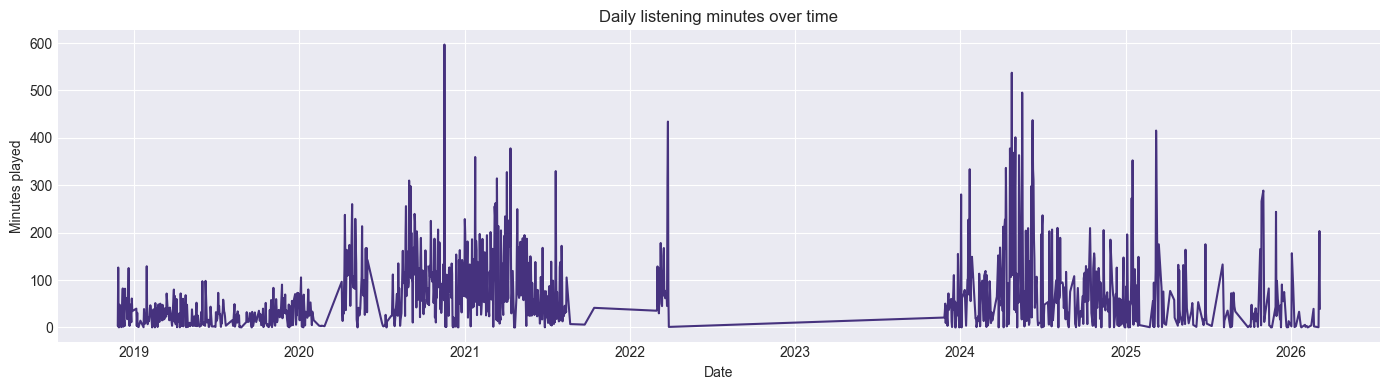

,minutes_played
count,1186.000000
mean,67.488459
std,75.204043
min,0.000000
25%,14.712908
50%,43.513117
75%,96.409471
max,596.930367


In [7]:
daily = df.groupby('date', as_index=False)['minutes_played'].sum()
plt.figure(figsize=(14, 4))
plt.plot(daily['date'], daily['minutes_played'])
plt.title('Daily listening minutes over time')
plt.xlabel('Date')
plt.ylabel('Minutes played')
plt.tight_layout()
plt.show()
daily.describe()

## Top artists and tracks

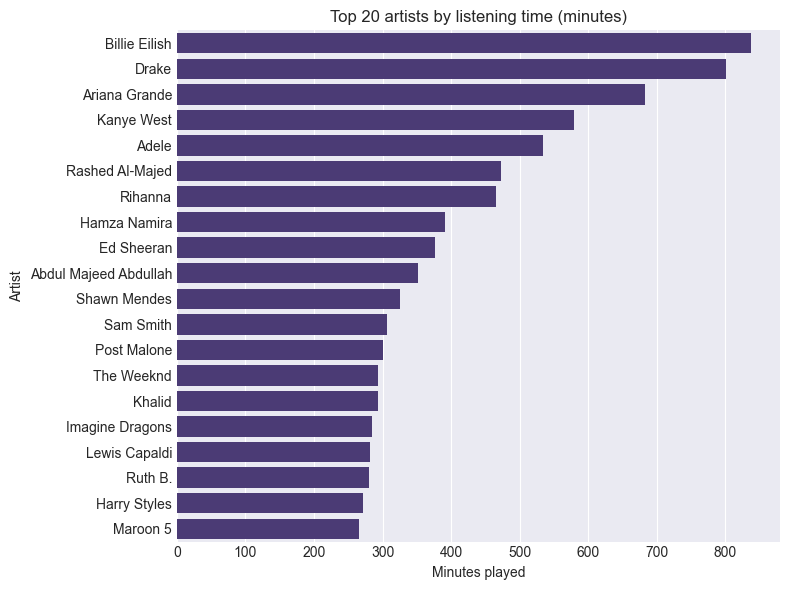

,artist,minutes_played
737,Billie Eilish,837.667967
1557,Drake,800.947717
453,Ariana Grande,682.049417
2882,Kanye West,578.848500
171,Adele,533.342417
4587,Rashed Al-Majed,472.034300
4662,Rihanna,465.046117
2219,Hamza Namira,390.709350
1641,Ed Sheeran,375.815583
131,Abdul Majeed Abdullah,352.323750


In [8]:
top_artists = (
    df.dropna(subset=['artist'])
      .groupby('artist', as_index=False)['minutes_played']
      .sum()
      .sort_values('minutes_played', ascending=False)
      .head(20)
)
plt.figure(figsize=(8, 6))
sns.barplot(data=top_artists, y='artist', x='minutes_played')
plt.title('Top 20 artists by listening time (minutes)')
plt.xlabel('Minutes played')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()
top_artists

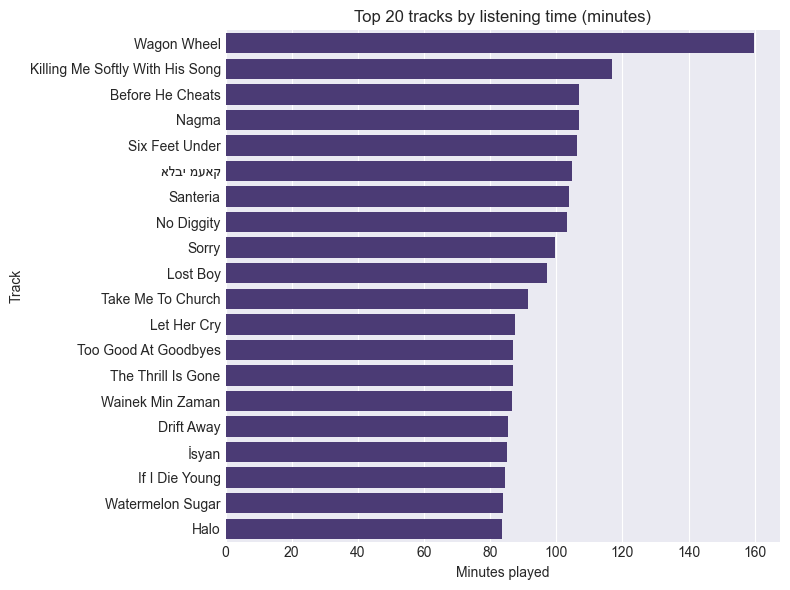

,track,artist,minutes_played
11141,Wagon Wheel,Darius Rucker,159.662783
5699,Killing Me Softly With His Song,Fugees,116.830217
1340,Before He Cheats,Carrie Underwood,107.014717
7333,Nagma,King Khalid,106.764750
9333,Six Feet Under,Billie Eilish,106.410033
12701,אלבי מעאק,Nasrin Kadri,104.792583
8910,Santeria,Sublime,103.953500
7482,No Diggity,Blackstreet,103.345100
9595,Sorry,Halsey,99.471667
6329,Lost Boy,Ruth B.,97.303033


In [9]:
top_tracks = (
    df.dropna(subset=['track'])
      .groupby(['track', 'artist'], as_index=False)['minutes_played']
      .sum()
      .sort_values('minutes_played', ascending=False)
      .head(20)
)
plt.figure(figsize=(8, 6))
sns.barplot(data=top_tracks, y='track', x='minutes_played')
plt.title('Top 20 tracks by listening time (minutes)')
plt.xlabel('Minutes played')
plt.ylabel('Track')
plt.tight_layout()
plt.show()
top_tracks

## When you listen (time of day & day of week)

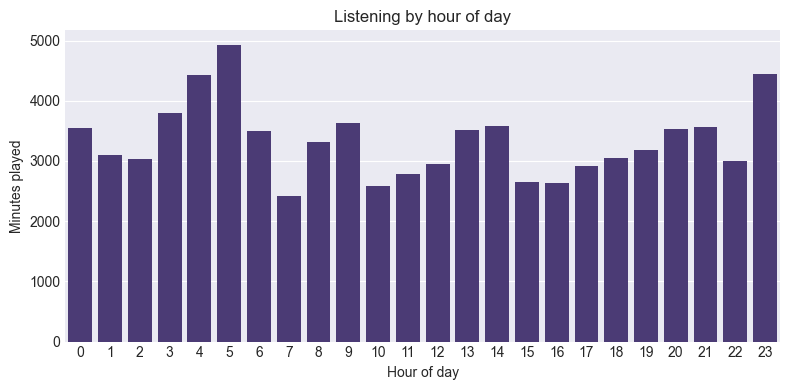

,hour,minutes_played
0,0,3542.850683
1,1,3097.963850
2,2,3034.526317
3,3,3796.658350
4,4,4431.793883
5,5,4922.408100
6,6,3497.205800
7,7,2416.916550
8,8,3306.870183
9,9,3635.130467


In [10]:
hourly = df.groupby('hour', as_index=False)['minutes_played'].sum()
plt.figure(figsize=(8, 4))
sns.barplot(data=hourly, x='hour', y='minutes_played')
plt.title('Listening by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('Minutes played')
plt.tight_layout()
plt.show()
hourly

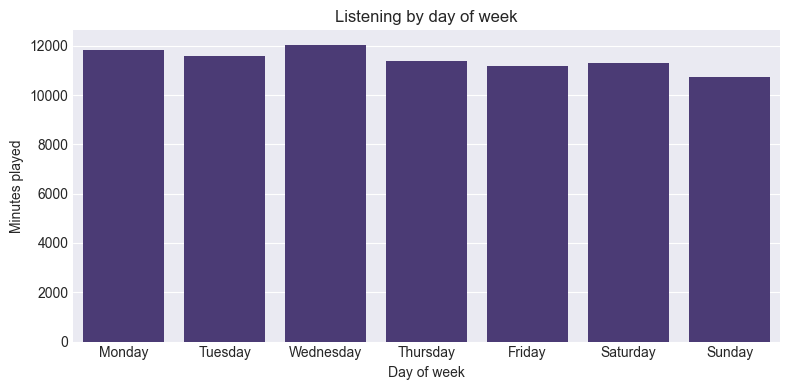

,dayofweek,minutes_played
1,Monday,11827.644083
5,Tuesday,11599.709617
6,Wednesday,12022.542183
4,Thursday,11367.242600
0,Friday,11166.164183
2,Saturday,11320.423217
3,Sunday,10737.586517


In [11]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = (
    df.groupby('dayofweek', as_index=False)['minutes_played']
      .sum()
      .assign(dayofweek=lambda d: pd.Categorical(d['dayofweek'], categories=dow_order, ordered=True))
      .sort_values('dayofweek')
)
plt.figure(figsize=(8, 4))
sns.barplot(data=dow, x='dayofweek', y='minutes_played')
plt.title('Listening by day of week')
plt.xlabel('Day of week')
plt.ylabel('Minutes played')
plt.tight_layout()
plt.show()
dow

## Artists and all songs you listened to

In [12]:
artist_tracks = (
    df.dropna(subset=['artist', 'track'])
      .groupby(['artist', 'track'], as_index=False)
      .agg(
          total_minutes=('minutes_played', 'sum'),
          play_count=('spotify_track_uri', 'count')
      )
      .sort_values(['artist', 'track'])
)

artist_tracks.head(50)  # first 50 rows as a preview

,artist,track,total_minutes,play_count
0,#Relaxing,Listen To The Ocean,2.200000,1
1,$NOT,FALL IN LOVE,1.046767,1
2,$NOT,GOSHA,2.054050,3
3,$NOT,Mean,2.097550,1
4,$NOT,Moon & Stars (feat. Maggie Lindemann),3.126433,1
5,$NOT,Revenge,2.468217,1
6,$hyfromdatre,Go Bestfriend,2.048800,19
7,$ilkMoney,My Potna Dem,4.934750,19
8,$wizzz,Weh mi Duh,0.815283,1
9,((( O ))),iFeel,4.527450,2


## Per-artist catalog summary (clean table)

This table shows, for each artist, how many different songs you listened to and the total listening time.

In [13]:
artist_summary = (
    artist_tracks
      .groupby('artist', as_index=False)
      .agg(
          unique_songs=('track', 'nunique'),
          total_minutes=('total_minutes', 'sum'),
          total_plays=('play_count', 'sum')
      )
      .sort_values('total_minutes', ascending=False)
)

artist_summary.head(50)  # top 50 artists by time listened

,artist,unique_songs,total_minutes,total_plays
737,Billie Eilish,60,837.667967,897
1557,Drake,53,800.947717,707
453,Ariana Grande,49,682.049417,824
2882,Kanye West,42,578.848500,371
171,Adele,41,533.342417,531
4587,Rashed Al-Majed,86,472.034300,490
4662,Rihanna,38,465.046117,604
2219,Hamza Namira,33,390.709350,362
1641,Ed Sheeran,42,375.815583,462
131,Abdul Majeed Abdullah,51,352.323750,346


## Year-by-year summary

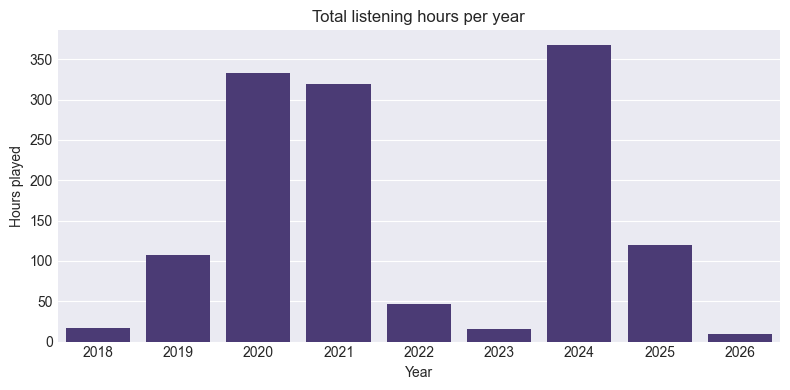

,year,minutes_played,hours,days
0,2018,987.065217,16.451087,0.685462
1,2019,6464.490867,107.741514,4.489230
2,2020,19958.103783,332.635063,13.859794
3,2021,19122.345000,318.705750,13.279406
4,2022,2785.808150,46.430136,1.934589
5,2023,911.024800,15.183747,0.632656
6,2024,22039.102917,367.318382,15.304933
7,2025,7175.991900,119.599865,4.983328
8,2026,597.379767,9.956329,0.414847


In [14]:
year_summary = (
    df.groupby('year', as_index=False)['minutes_played']
      .sum()
      .assign(hours=lambda d: d['minutes_played'] / 60,
              days=lambda d: d['minutes_played'] / 60 / 24)
)
plt.figure(figsize=(8, 4))
sns.barplot(data=year_summary, x='year', y='hours')
plt.title('Total listening hours per year')
plt.xlabel('Year')
plt.ylabel('Hours played')
plt.tight_layout()
plt.show()
year_summary